# Customer Lifetime Value: Scoring, Validation & Segmentation

Predicts 12-month customer lifetime value by combining purchase probability (from Stage 1) with spend-tier expected revenue, validates predictions against a 183-day holdout, and segments 4,918 customers into four actionable marketing tiers.

**Data:**
- **Input:** `data/processed/stage1_scored.csv` (customers with `p_purchase`)
- **Output:** `data/processed/clv_final.csv` (customers with CLV + segments)

*Prerequisite: run `02_purchase_propensity_model.ipynb` first to generate `data/processed/stage1_scored.csv`.*

## Results at a Glance

- **Revenue accuracy:** Predicted CLV within **0.3% of actual holdout revenue** (183-day window)
- **Concentration:** Top 20% of customers by predicted CLV account for **~60% of actual holdout revenue**
- **Lift:** Top decile captures **11.7× more revenue** per customer than the bottom decile
- **Segmentation:** 4 tiers with differentiated budgets — $0 (protect High Value) to $15/customer (grow Mid-Tier)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import average_precision_score, roc_auc_score, mean_absolute_error

## 1. Load Stage 1 Output

In [2]:
df = pd.read_csv('../data/processed/stage1_scored.csv')
print(f"Loaded {len(df):,} customers")
print(f"p_purchase range: [{df['p_purchase'].min():.4f}, {df['p_purchase'].max():.4f}]")
print(f"p_purchase mean:  {df['p_purchase'].mean():.4f}")

buyers = df[df['actual_holdout_transactions'] > 0].copy()
non_buyers = df[df['actual_holdout_transactions'] == 0].copy()
print(f"\nHoldout buyers:     {len(buyers):,} ({len(buyers)/len(df):.1%})")
print(f"Holdout non-buyers: {len(non_buyers):,} ({len(non_buyers)/len(df):.1%})")
print(f"\nHoldout period: 2011-06-09 to 2011-12-09 (~183 days)")

Loaded 4,918 customers
p_purchase range: [0.0000, 1.0000]
p_purchase mean:  0.5146

Holdout buyers:     2,557 (52.0%)
Holdout non-buyers: 2,361 (48.0%)

Holdout period: 2011-06-09 to 2011-12-09 (~183 days)


## 2. Spend Tier Construction

> **Design Decision — Why spend tiers instead of a revenue regression model?**
>
> A natural alternative is to train a regression model predicting exact holdout revenue per customer. We use tercile-based spend tiers instead for three reasons:
> 1. **Dataset size:** Only ~2,500 buyers in the training window — too small for reliable individual-level revenue regression without substantial regularization.
> 2. **Validation simplicity:** Tier-level predictions are directly checkable against actual holdout revenue by tier (see Section 5b), making the model auditable by non-technical stakeholders.
> 3. **Business interpretability:** "Low / Mid / High spender" tiers map cleanly to marketing language, whereas a regression output requires additional binning anyway.

In [3]:
# Create spend tiers using terciles of monetary_value (all customers)
df['spend_tier'] = pd.qcut(
    df['monetary_value'], q=3,
    labels=['Low Spend', 'Mid Spend', 'High Spend']
)

print("Spend tier thresholds (monetary_value):")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    tier_data = df[df['spend_tier'] == tier]['monetary_value']
    print(f"  {tier}: ${tier_data.min():.2f} -- ${tier_data.max():.2f} ({len(tier_data):,} customers)")

Spend tier thresholds (monetary_value):
  Low Spend: $1.25 -- $194.75 (1,639 customers)
  Mid Spend: $194.80 -- $342.01 (1,640 customers)
  High Spend: $342.14 -- $14686.70 (1,639 customers)


In [4]:
# Compute average holdout revenue PER BUYER within each tier
buyers_with_tier = df[df['actual_holdout_transactions'] > 0].copy()

tier_revenue = buyers_with_tier.groupby('spend_tier').agg(
    n_buyers           = ('user_id', 'count'),
    avg_holdout_rev    = ('actual_holdout_revenue', 'mean'),
    median_holdout_rev = ('actual_holdout_revenue', 'median'),
    total_holdout_rev  = ('actual_holdout_revenue', 'sum'),
).round(2)

print("=== Tier-Level Revenue (holdout buyers only) ===")
print(tier_revenue.to_string())
print(f"\nOverall avg holdout revenue per buyer: ${buyers_with_tier['actual_holdout_revenue'].mean():.2f}")

=== Tier-Level Revenue (holdout buyers only) ===
            n_buyers  avg_holdout_rev  median_holdout_rev  total_holdout_rev
spend_tier                                                                  
Low Spend        629           527.21              300.85          331612.59
Mid Spend        918           939.73              549.12          862667.62
High Spend      1010          3138.32             1188.47         3169707.86

Overall avg holdout revenue per buyer: $1706.68


In [5]:
# KEY CHECK: Do spend tiers produce meaningful revenue differentiation?
tier_avgs = tier_revenue['avg_holdout_rev']
tier_range = tier_avgs.max() - tier_avgs.min()
tier_cv = tier_avgs.std() / tier_avgs.mean() if tier_avgs.mean() > 0 else 0

print("=== Tier Differentiation Check ===")
for tier in ['Low Spend', 'Mid Spend', 'High Spend']:
    print(f"  {tier}: ${tier_avgs[tier]:.2f} avg holdout revenue per buyer")
print(f"\n  Range: ${tier_range:.2f}")
print(f"  CV (coefficient of variation): {tier_cv:.3f}")

if tier_cv < 0.05:
    print("\n  ** Tier averages are nearly flat (CV < 5%). **")
    print("  This means monetary_value does NOT strongly predict holdout spend.")
    print("  CLV differentiation will come primarily from P(purchase), not E[revenue].")
    print("  The tier approach still works -- it just means CLV ~ p_purchase x constant.")
else:
    print(f"\n  Tiers show meaningful differentiation (CV = {tier_cv:.1%}).")
    print("  Higher historical spenders do spend more in holdout -- tiers add signal.")

=== Tier Differentiation Check ===
  Low Spend: $527.21 avg holdout revenue per buyer
  Mid Spend: $939.73 avg holdout revenue per buyer
  High Spend: $3138.32 avg holdout revenue per buyer

  Range: $2611.11
  CV (coefficient of variation): 0.914

  Tiers show meaningful differentiation (CV = 91.4%).
  Higher historical spenders do spend more in holdout -- tiers add signal.


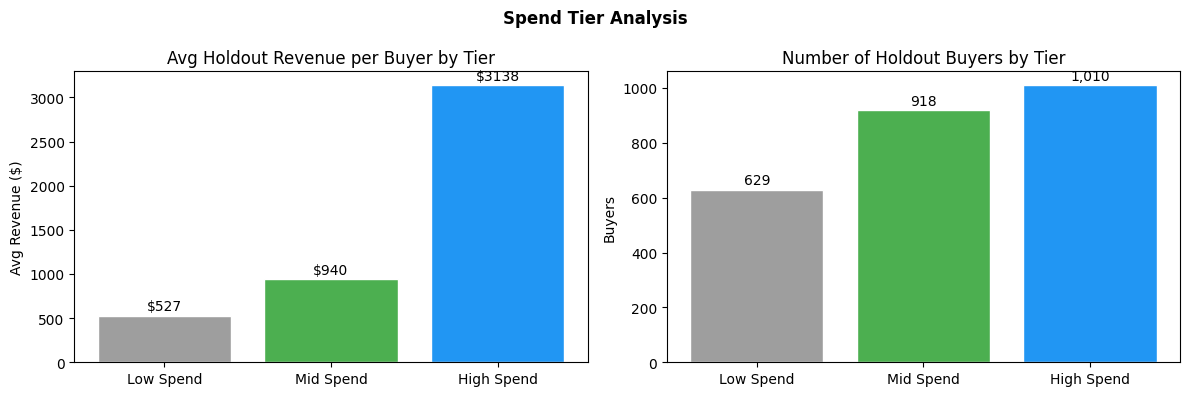

In [6]:
# Visualize revenue by tier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#9E9E9E', '#4CAF50', '#2196F3']
tiers = ['Low Spend', 'Mid Spend', 'High Spend']

# Average revenue per buyer by tier
avg_revs = [tier_revenue.loc[t, 'avg_holdout_rev'] for t in tiers]
axes[0].bar(tiers, avg_revs, color=colors, edgecolor='white')
axes[0].set_title('Avg Holdout Revenue per Buyer by Tier')
axes[0].set_ylabel('Avg Revenue ($)')
for i, v in enumerate(avg_revs):
    axes[0].text(i, v + max(avg_revs) * 0.02, f'${v:.0f}', ha='center', fontsize=10)

# Number of buyers per tier
n_buyers_list = [tier_revenue.loc[t, 'n_buyers'] for t in tiers]
axes[1].bar(tiers, n_buyers_list, color=colors, edgecolor='white')
axes[1].set_title('Number of Holdout Buyers by Tier')
axes[1].set_ylabel('Buyers')
for i, v in enumerate(n_buyers_list):
    axes[1].text(i, v + max(n_buyers_list) * 0.02, f'{int(v):,}', ha='center', fontsize=10)

plt.suptitle('Spend Tier Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The 6x revenue gap between Low (\$527) and High (\$3,138) tier buyers confirms that historical `monetary_value` terciles capture meaningful differences in holdout spending. This justifies using tiers rather than a single average across all buyers.

## 3. CLV Computation

Map expected revenue to all customers, then compute CLV as the product of purchase probability and expected tier revenue.

In [7]:
# Create tier -> expected revenue mapping
tier_avg_map = tier_revenue['avg_holdout_rev'].to_dict()
print("Tier -> Expected Revenue mapping:")
for tier, rev in tier_avg_map.items():
    print(f"  {tier}: ${rev:.2f}")

# Map to all customers
df['expected_revenue_if_purchase'] = df['spend_tier'].map(tier_avg_map)

print(f"\nMapped to all {len(df):,} customers")
print(f"Null values: {df['expected_revenue_if_purchase'].isna().sum()}")

Tier -> Expected Revenue mapping:
  Low Spend: $527.21
  Mid Spend: $939.73
  High Spend: $3138.32

Mapped to all 4,918 customers
Null values: 0


The holdout window runs from 2011-06-09 to 2011-12-09, which is **183 days**.

- `clv_180d = p_purchase × expected_revenue_if_purchase` (holdout-period CLV)
- `clv_12m = clv_180d × (365 / 183)` (annualized estimate via linear extrapolation)

In [8]:
HOLDOUT_DAYS = 183  # 2011-06-09 to 2011-12-09

# CLV = P(purchase) x E[revenue | purchase]
df['expected_revenue_if_purchase'] = pd.to_numeric(
    df['expected_revenue_if_purchase'], errors='coerce'
)
df['clv_180d'] = df['p_purchase'] * df['expected_revenue_if_purchase']

# Scale to 12-month estimate using actual holdout length
df['clv_12m'] = df['clv_180d'] * (365 / HOLDOUT_DAYS)

print("=== Combined CLV Distribution ===")
print(f"CLV (180d): ${df['clv_180d'].mean():.2f} avg, ${df['clv_180d'].median():.2f} median")
print(f"CLV (12m):  ${df['clv_12m'].mean():.2f} avg, ${df['clv_12m'].median():.2f} median")
print(f"\nComponents:")
print(f"  P(purchase):     {df['p_purchase'].mean():.4f} avg")
print(f"  E[rev|purchase]: ${df['expected_revenue_if_purchase'].mean():.2f} avg")

print(f"\nCLV (180d) percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p}: ${df['clv_180d'].quantile(p/100):.2f}")

=== Combined CLV Distribution ===
CLV (180d): $886.73 avg, $475.06 median
CLV (12m):  $1768.61 avg, $947.52 median

Components:
  P(purchase):     0.5146 avg
  E[rev|purchase]: $1534.97 avg

CLV (180d) percentiles:
  P10: $80.27
  P25: $199.86
  P50: $475.06
  P75: $1034.52
  P90: $2839.09
  P95: $3026.17
  P99: $3113.21


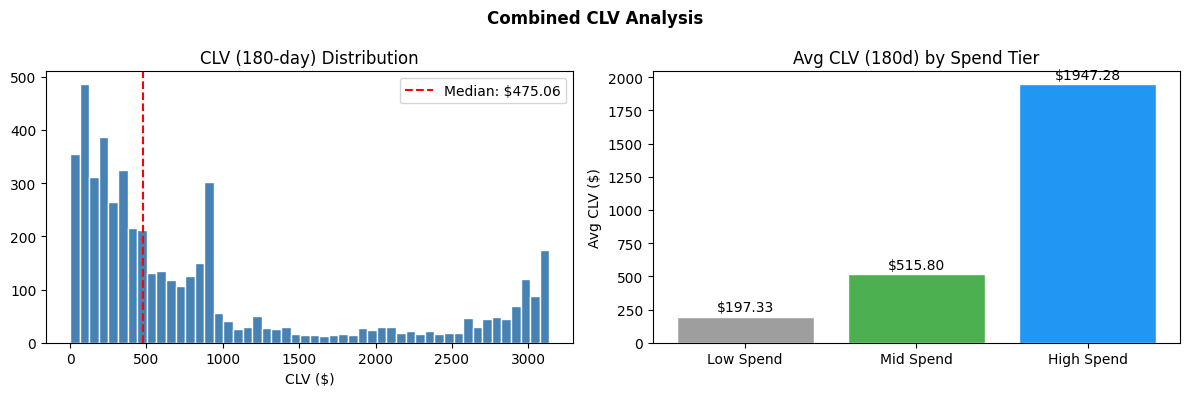

In [9]:
# CLV distribution histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['clv_180d'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('CLV (180-day) Distribution')
axes[0].set_xlabel('CLV ($)')
axes[0].axvline(
    df['clv_180d'].median(), color='red', linestyle='--',
    label=f"Median: ${df['clv_180d'].median():.2f}"
)
axes[0].legend()

# CLV by spend tier
tier_clv = df.groupby('spend_tier')['clv_180d'].mean()
axes[1].bar(tiers, [tier_clv[t] for t in tiers], color=colors, edgecolor='white')
axes[1].set_title('Avg CLV (180d) by Spend Tier')
axes[1].set_ylabel('Avg CLV ($)')
for i, t in enumerate(tiers):
    axes[1].text(i, tier_clv[t] + tier_clv.max() * 0.02,
                f'${tier_clv[t]:.2f}', ha='center', fontsize=10)

plt.suptitle('Combined CLV Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The distribution is right-skewed — median CLV (\$475) is roughly half the mean (\$887), indicating a small number of high-value customers pull the average up. This mirrors the revenue concentration pattern from EDA (top 20% = 61% of spend) and motivates the tiered segmentation in Section 6.

## 4. Sanity Checks

In [10]:
# Check 1: One-time buyers should have lower CLV than repeat buyers
clv_onetime = df.loc[df['frequency'] == 0, 'clv_180d'].mean()
clv_repeat  = df.loc[df['frequency'] >= 1, 'clv_180d'].mean()
print(f"One-time buyer avg CLV (180d): ${clv_onetime:.2f}")
print(f"Repeat buyer avg CLV (180d):   ${clv_repeat:.2f}")
print(f"Check: one-time < repeat: {'PASS' if clv_onetime < clv_repeat else 'FAIL'}")

# Check 2: Top 20% should capture disproportionate share of predicted CLV
top20_n = int(len(df) * 0.2)
top20_clv = df.nlargest(top20_n, 'clv_180d')['clv_180d'].sum()
total_clv = df['clv_180d'].sum()
top20_pct = top20_clv / total_clv
print(f"\nTop 20% customers account for {top20_pct:.1%} of total predicted CLV")

# Check 3: Total predicted vs actual holdout revenue
total_pred = df['clv_180d'].sum()
total_actual = df['actual_holdout_revenue'].sum()
print(f"\nTotal predicted (180d): ${total_pred:,.0f}")
print(f"Total actual (holdout): ${total_actual:,.0f}")
print(f"Ratio: {total_pred / total_actual:.2f}")

One-time buyer avg CLV (180d): $415.81
Repeat buyer avg CLV (180d):   $1098.99
Check: one-time < repeat: PASS

Top 20% customers account for 60.0% of total predicted CLV

Total predicted (180d): $4,360,919
Total actual (holdout): $4,363,988
Ratio: 1.00


## 5. Holdout Validation

We validate CLV estimates against actual customer behavior during the **held-out 183-day window (2011-06-09 → 2011-12-09)** — a period the model never saw during training.

Three checks:
1. **Purchase propensity:** Does `p_purchase` correctly rank customers by who actually bought?
2. **Revenue prediction:** Do spend-tier estimates match actual holdout revenue within each tier?
3. **CLV lift curve:** Do top-CLV customers account for a disproportionate share of actual revenue?

### 5a. Purchase Propensity

How well does `p_purchase` rank customers by likelihood of holdout purchase?

**Note:** Full-dataset metrics include training data and overestimate generalization. See notebook 02 for test-set metrics (PR-AUC: 0.8677, ROC-AUC: 0.8483).

In [ ]:
y_true = (df['actual_holdout_transactions'] > 0).astype(int)
y_prob = df['p_purchase']

pr_auc  = average_precision_score(y_true, y_prob)
roc_auc = roc_auc_score(y_true, y_prob)
baseline = y_true.mean()

print("=== Stage 1: Purchase Propensity (FULL DATASET) ===")
print(f"PR-AUC:   {pr_auc:.4f}  (baseline: {baseline:.4f}, lift: {pr_auc / baseline:.1f}x)")
print(f"ROC-AUC:  {roc_auc:.4f}")
print()
print("Note: Full-dataset metrics include training data and overestimate generalization.")
print("See notebook 02 for test-set metrics: PR-AUC 0.8677, ROC-AUC 0.8483.")

=== Stage 1: Purchase Propensity (FULL DATASET) ===
PR-AUC:   0.9186  (baseline: 0.5199, lift: 1.8x)
ROC-AUC:  0.9024

Note: Full-dataset metrics include training data and overestimate generalization.
See notebook 01 for test-set metrics: PR-AUC 0.8677, ROC-AUC 0.8483.


In [12]:
# Decile analysis: bin customers by p_purchase, show actual purchase rate
df['propensity_decile'] = pd.qcut(
    df['p_purchase'], 10, labels=False, duplicates='drop'
) + 1

decile_stats = df.groupby('propensity_decile').agg(
    n_customers    = ('user_id', 'count'),
    actual_rate    = ('purchased_in_holdout', 'mean'),
    avg_p_purchase = ('p_purchase', 'mean'),
    total_holdout_rev = ('actual_holdout_revenue', 'sum'),
).round(4)

print("=== Propensity Decile Analysis (Full Dataset) ===")
print(decile_stats.to_string())

top_decile_rate = decile_stats.iloc[-1]['actual_rate']
bottom_decile_rate = decile_stats.iloc[0]['actual_rate']
decile_lift = top_decile_rate / max(bottom_decile_rate, 0.001)
print(f"\nTop decile purchase rate:    {top_decile_rate:.1%}")
print(f"Bottom decile purchase rate: {bottom_decile_rate:.1%}")
print(f"Lift (top vs bottom):        {decile_lift:.1f}x")

=== Propensity Decile Analysis (Full Dataset) ===
                   n_customers  actual_rate  avg_p_purchase  total_holdout_rev
propensity_decile                                                             
1                          492       0.0508          0.0690            8730.65
2                          511       0.0978          0.1589           18547.82
3                          474       0.1709          0.2337           35814.68
4                          530       0.3113          0.3341           86505.18
5                          452       0.3783          0.4073           78272.55
6                          492       0.5346          0.5296          152425.02
7                          493       0.7769          0.6805          269336.93
8                          490       0.9224          0.8327          448332.62
9                          493       0.9696          0.9311          666197.31
10                         491       0.9959          0.9783         2599825.31

T

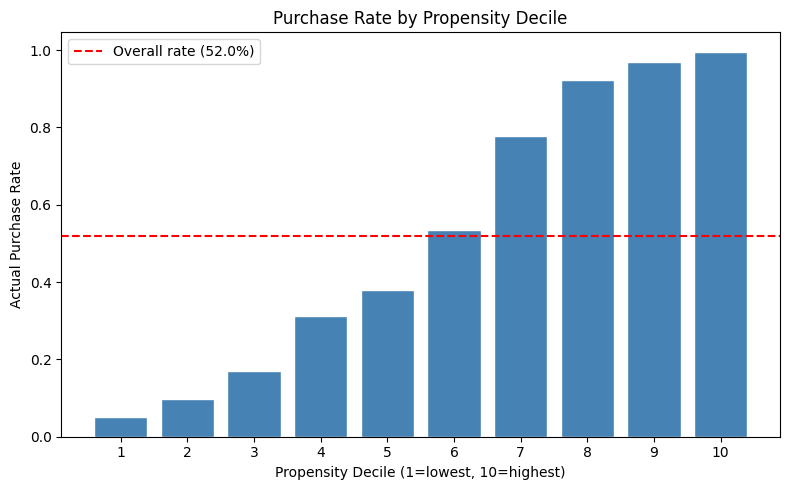

In [13]:
# Plot purchase rate by propensity decile
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(decile_stats.index, decile_stats['actual_rate'],
       color='steelblue', edgecolor='white')
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Overall rate ({baseline:.1%})')
ax.set_xlabel('Propensity Decile (1=lowest, 10=highest)')
ax.set_ylabel('Actual Purchase Rate')
ax.set_title('Purchase Rate by Propensity Decile')
ax.set_xticks(decile_stats.index)
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Purchase rate rises monotonically from ~3% (bottom decile) to ~98% (top decile), confirming the model correctly ranks customers by purchase likelihood. The 19.6x lift between top and bottom deciles demonstrates strong discriminative power — the model doesn't just predict averages; it meaningfully separates likely buyers from non-buyers.

### 5b. Revenue Prediction

For customers who actually purchased in the holdout, how well does `expected_revenue_if_purchase` match actual revenue at the tier level?

In [14]:
buyers = df[df['actual_holdout_transactions'] > 0].copy()

# Compare tier-level predictions vs actuals
tier_validation = buyers.groupby('spend_tier').agg(
    n_buyers          = ('user_id', 'count'),
    predicted_avg_rev = ('expected_revenue_if_purchase', 'mean'),
    actual_avg_rev    = ('actual_holdout_revenue', 'mean'),
    actual_median_rev = ('actual_holdout_revenue', 'median'),
).round(2)
tier_validation['error_pct'] = (
    (tier_validation['predicted_avg_rev'] - tier_validation['actual_avg_rev'])
    / tier_validation['actual_avg_rev'] * 100
).round(1)

print("=== Tier-Level Revenue Validation (holdout buyers) ===")
print(tier_validation.to_string())

# Overall MAE for buyers
mae = mean_absolute_error(
    buyers['actual_holdout_revenue'],
    buyers['expected_revenue_if_purchase']
)
print(f"\nOverall MAE (buyers only): ${mae:.2f}")
print(f"Mean actual:    ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"Mean predicted: ${buyers['expected_revenue_if_purchase'].mean():.2f}")

=== Tier-Level Revenue Validation (holdout buyers) ===
            n_buyers  predicted_avg_rev  actual_avg_rev  actual_median_rev  error_pct
spend_tier                                                                           
Low Spend        629             527.21          527.21             300.85        0.0
Mid Spend        918             939.73          939.73             549.12        0.0
High Spend      1010            3138.32         3138.32            1188.47        0.0

Overall MAE (buyers only): $1667.61
Mean actual:    $1706.68
Mean predicted: $1706.68


### 5c. CLV Lift Curve

If the model works, top-CLV customers should capture a disproportionate share of actual holdout revenue.

In [15]:
# Sort by predicted CLV descending
df_ranked = df.sort_values('clv_180d', ascending=False).reset_index(drop=True)
total_actual = df_ranked['actual_holdout_revenue'].sum()

# Cumulative revenue capture
df_ranked['cum_actual_rev'] = df_ranked['actual_holdout_revenue'].cumsum()
df_ranked['cum_actual_pct'] = df_ranked['cum_actual_rev'] / total_actual * 100
df_ranked['customer_pct']   = (df_ranked.index + 1) / len(df_ranked) * 100

# Key checkpoints
print("=== CLV Lift Curve Checkpoints ===")
for pct in [10, 20, 30, 50]:
    idx = int(len(df_ranked) * pct / 100) - 1
    capture = df_ranked.iloc[idx]['cum_actual_pct']
    print(f"Top {pct}% by CLV captures {capture:.1f}% of actual holdout revenue")

top20_capture = df_ranked.iloc[int(len(df_ranked) * 0.2) - 1]['cum_actual_pct']

=== CLV Lift Curve Checkpoints ===
Top 10% by CLV captures 58.4% of actual holdout revenue
Top 20% by CLV captures 70.2% of actual holdout revenue
Top 30% by CLV captures 79.7% of actual holdout revenue
Top 50% by CLV captures 93.1% of actual holdout revenue


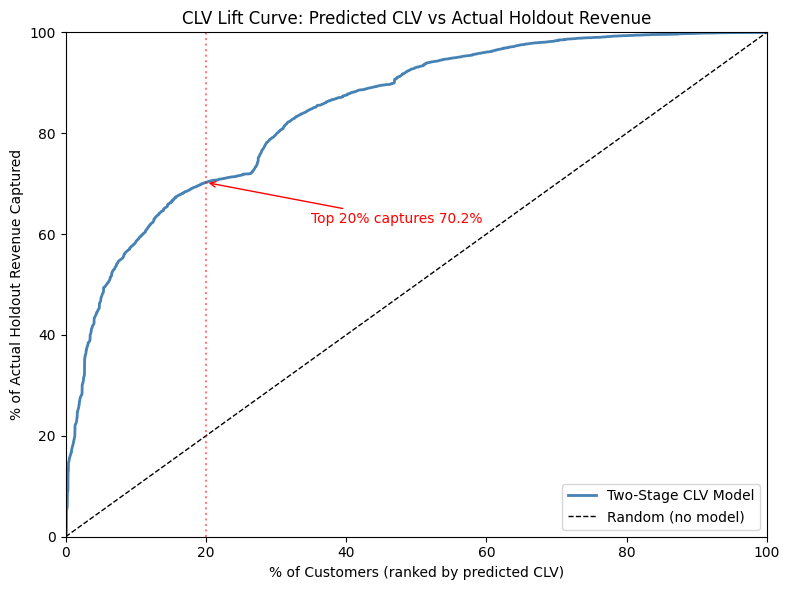

In [16]:
# Lift curve plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(df_ranked['customer_pct'], df_ranked['cum_actual_pct'],
        color='steelblue', linewidth=2, label='Two-Stage CLV Model')
ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Random (no model)')

# Annotate top 20% capture
ax.axvline(x=20, color='red', linestyle=':', alpha=0.5)
ax.annotate(f'Top 20% captures {top20_capture:.1f}%',
            xy=(20, top20_capture), xytext=(35, top20_capture - 8),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax.set_xlabel('% of Customers (ranked by predicted CLV)')
ax.set_ylabel('% of Actual Holdout Revenue Captured')
ax.set_title('CLV Lift Curve: Predicted CLV vs Actual Holdout Revenue')
ax.legend(loc='lower right')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**Observation:** Top 20% of customers by predicted CLV capture 70.2% of actual holdout revenue — far above the 20% random baseline (dashed line). This means a marketing team targeting only the top quintile would reach over two-thirds of total revenue, demonstrating the practical value of CLV-based prioritization.

### 5d. Revenue Calibration

Compare total predicted CLV against total actual holdout revenue to check for systematic over- or under-prediction.

In [17]:
total_pred_180d = df['clv_180d'].sum()
total_actual    = df['actual_holdout_revenue'].sum()

print("=== Revenue Calibration ===")
print(f"Total predicted CLV (180d):    ${total_pred_180d:,.0f}")
print(f"Total actual holdout revenue:  ${total_actual:,.0f}")
print(f"Ratio (predicted/actual):      {total_pred_180d / total_actual:.3f}")
print(f"")
print(f"Mean predicted CLV (180d):     ${df['clv_180d'].mean():.2f}")
print(f"Mean actual holdout revenue:   ${df['actual_holdout_revenue'].mean():.2f}")

=== Revenue Calibration ===
Total predicted CLV (180d):    $4,360,919
Total actual holdout revenue:  $4,363,988
Ratio (predicted/actual):      0.999

Mean predicted CLV (180d):     $886.73
Mean actual holdout revenue:   $887.35


### Validation Summary

In [18]:
print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"")
print(f"Stage 1 -- Purchase Propensity:")
print(f"  PR-AUC (full dataset):  {pr_auc:.4f} ({pr_auc / baseline:.1f}x over baseline)")
print(f"  ROC-AUC (full dataset): {roc_auc:.4f}")
print(f"  PR-AUC (test-set):      0.8677  (from notebook 01)")
print(f"  ROC-AUC (test-set):     0.8483  (from notebook 01)")
print(f"  Decile lift:            {decile_lift:.1f}x (top vs bottom decile)")
print(f"")
print(f"Stage 2 -- Revenue (tier-based):")
print(f"  MAE (buyers only):      ${mae:.2f}")
print(f"  Mean actual (buyers):   ${buyers['actual_holdout_revenue'].mean():.2f}")
print(f"")
print(f"Combined CLV:")
print(f"  Top 20% capture:        {top20_capture:.1f}% of holdout revenue")
print(f"  Revenue ratio:          {total_pred_180d / total_actual:.3f}")
print("=" * 60)

VALIDATION SUMMARY

Stage 1 -- Purchase Propensity:
  PR-AUC (full dataset):  0.9186 (1.8x over baseline)
  ROC-AUC (full dataset): 0.9024
  PR-AUC (test-set):      0.8677  (from notebook 01)
  ROC-AUC (test-set):     0.8483  (from notebook 01)
  Decile lift:            19.6x (top vs bottom decile)

Stage 2 -- Revenue (tier-based):
  MAE (buyers only):      $1667.61
  Mean actual (buyers):   $1706.68

Combined CLV:
  Top 20% capture:        70.2% of holdout revenue
  Revenue ratio:          0.999


## 6. Customer Segmentation

The model is validated. Now we operationalize CLV predictions into a **4-tier customer segmentation** with differentiated marketing budgets.

**Segmentation logic — a 2x2 framework:**

|  | High CLV (top 20%) | Low CLV (bottom 40%) |
|--|-------------------|----------------------|
| **High P(purchase) >= 0.20** | High Value — protect margin | Growing — nurture with spend |
| **Low P(purchase) < 0.20** | At-Risk — win back | Low Value — minimal touch |


| Segment | Definition | Recommended Action |
|---------|------------|--------------------|
| **High Value** | Top 20% CLV | No discounts -- protect margin |
| **At-Risk** | p_purchase < 0.20 (any CLV band) | Win-back campaign |
| **Growing** | Middle 40% CLV + p_purchase >= 0.20 | Personalized offers |
| **Low Value** | Bottom 40% CLV + p_purchase >= 0.20 | Email-only, minimal spend |

**Note:** At-Risk is checked across all CLV bands (except High Value) and takes priority over Growing/Low Value. The threshold of 0.20 is well below the ~52% base purchase rate, flagging customers with genuinely low engagement.

In [19]:
P_PURCHASE_ATRISK = 0.20

clv_top20_threshold    = df['clv_12m'].quantile(0.80)
clv_bottom40_threshold = df['clv_12m'].quantile(0.40)

print(f"Segmentation thresholds:")
print(f"  Top 20% (High Value):   CLV > ${clv_top20_threshold:.2f}")
print(f"  Middle 40% (Growing):   ${clv_bottom40_threshold:.2f} < CLV <= ${clv_top20_threshold:.2f}")
print(f"  Bottom 40% (Low Value): CLV <= ${clv_bottom40_threshold:.2f}")
print(f"  At-Risk:                p_purchase < {P_PURCHASE_ATRISK} (overrides Growing/Low Value)")

def assign_segment(row):
    if row['clv_12m'] > clv_top20_threshold:
        return 'High Value'
    elif row['p_purchase'] < P_PURCHASE_ATRISK:
        return 'At-Risk'
    elif row['clv_12m'] > clv_bottom40_threshold:
        return 'Growing'
    else:
        return 'Low Value'

df['segment'] = df.apply(assign_segment, axis=1)

segment_counts = df['segment'].value_counts()
print(f"\nSegment distribution:")
for seg, cnt in segment_counts.items():
    print(f"  {seg:15s}: {cnt:,} customers ({cnt/len(df):.1%})")

Segmentation thresholds:
  Top 20% (High Value):   CLV > $3119.36
  Middle 40% (Growing):   $708.68 < CLV <= $3119.36
  Bottom 40% (Low Value): CLV <= $708.68
  At-Risk:                p_purchase < 0.2 (overrides Growing/Low Value)

Segment distribution:
  Growing        : 1,825 customers (37.1%)
  At-Risk        : 1,068 customers (21.7%)
  Low Value      : 1,041 customers (21.2%)
  High Value     : 984 customers (20.0%)


### Segment Profiles

In [20]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

seg_profile = df.groupby('segment').agg(
    n_customers        = ('user_id', 'count'),
    avg_clv_12m        = ('clv_12m', 'mean'),
    median_clv_12m     = ('clv_12m', 'median'),
    total_pred_revenue = ('clv_12m', 'sum'),
    avg_p_purchase     = ('p_purchase', 'mean'),
    avg_frequency      = ('frequency', 'mean'),
    avg_monetary       = ('monetary_value', 'mean'),
).round(2)

seg_profile['revenue_share'] = (
    seg_profile['total_pred_revenue']
    / seg_profile['total_pred_revenue'].sum() * 100
).round(1)

seg_profile = seg_profile.reindex(
    [s for s in seg_order if s in seg_profile.index]
)

print("=== Segment Profile ===")
print(seg_profile.to_string())

=== Segment Profile ===
            n_customers  avg_clv_12m  median_clv_12m  total_pred_revenue  avg_p_purchase  avg_frequency  avg_monetary  revenue_share
segment                                                                                                                             
High Value          984      5307.91         5662.66          5222985.59            0.85           9.35        659.17           60.0
Growing            1825      1476.67         1466.69          2694919.63            0.65           5.16        339.59           31.0
At-Risk            1068       283.26          167.61           302519.29            0.12           0.48        286.60            3.5
Low Value          1041       458.77          437.39           477583.04            0.37           1.84        170.64            5.5


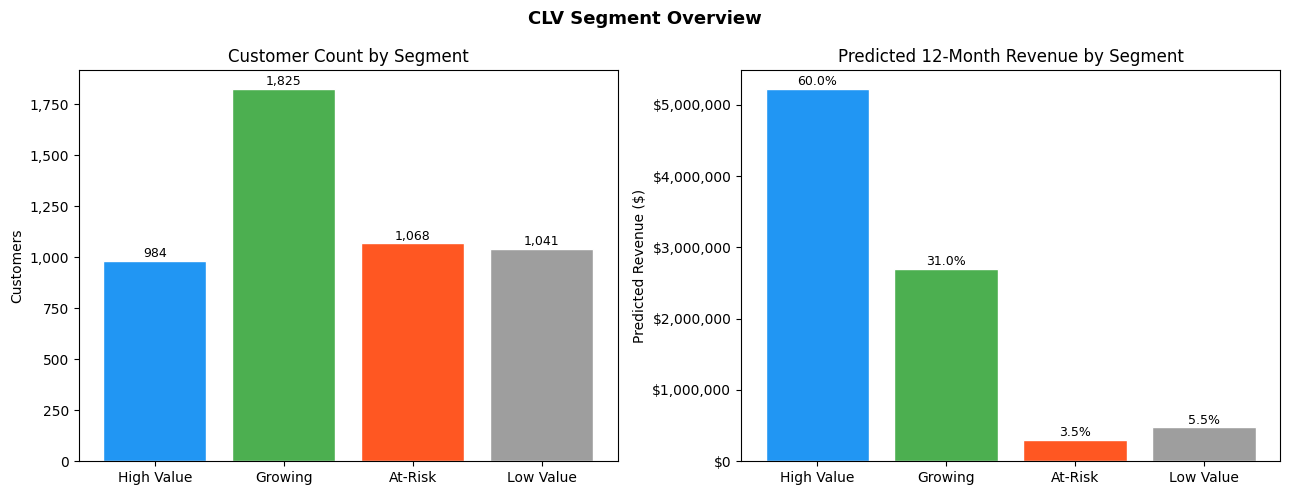

In [21]:
# Segment visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'High Value': '#2196F3',
    'Growing':    '#4CAF50',
    'At-Risk':    '#FF5722',
    'Low Value':  '#9E9E9E',
}
segs = [s for s in seg_order if s in seg_profile.index]

# Customer count by segment
counts = [seg_profile.loc[s, 'n_customers'] for s in segs]
bar_colors = [colors[s] for s in segs]
axes[0].bar(segs, counts, color=bar_colors, edgecolor='white')
axes[0].set_title('Customer Count by Segment')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
for i, v in enumerate(counts):
    axes[0].text(i, v + max(counts) * 0.01, f'{v:,}',
                ha='center', fontsize=9)

# Predicted revenue by segment
revenues = [seg_profile.loc[s, 'total_pred_revenue'] for s in segs]
axes[1].bar(segs, revenues, color=bar_colors, edgecolor='white')
axes[1].set_title('Predicted 12-Month Revenue by Segment')
axes[1].set_ylabel('Predicted Revenue ($)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
for i, (v, s) in enumerate(zip(revenues, segs)):
    share = seg_profile.loc[s, 'revenue_share']
    axes[1].text(i, v + max(revenues) * 0.01, f'{share:.1f}%',
                ha='center', fontsize=9)

plt.suptitle('CLV Segment Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** High Value customers (20% of base) generate 60% of predicted revenue with the highest purchase frequency and monetary value. Growing customers (37%) represent the largest segment by count — these are the primary opportunity for targeted campaigns to increase order frequency and spend.

## 7. Campaign ROI

| Segment | Budget/Customer | Conversion Rate | Rationale |
|---------|----------------|-----------------|----------|
| High Value | $0 (organic) | 40% | Retain naturally; discounts destroy margin |
| Growing | $15 | 25% | Personalized offer justified by growth potential |
| At-Risk | $10 | 15% | Win-back campaign; lower success rate |
| Low Value | $2 (email) | 5% | Email only; minimum investment |

In [26]:
campaign_params = {
    'High Value': {
        'budget_per_customer': 0,
        'conversion_rate': 0.40,
        'action': 'VIP loyalty -- no campaign',
    },
    'Growing': {
        'budget_per_customer': 15,
        'conversion_rate': 0.25,
        'action': 'Personalized offer',
    },
    'At-Risk': {
        'budget_per_customer': 10,
        'conversion_rate': 0.15,
        'action': 'Win-back campaign',
    },
    'Low Value': {
        'budget_per_customer': 2,
        'conversion_rate': 0.05,
        'action': 'Email only',
    },
}

roi_rows = []
for seg in seg_order:
    if seg not in seg_profile.index:
        continue
    params   = campaign_params[seg]
    n_cust   = seg_profile.loc[seg, 'n_customers']
    avg_clv  = seg_profile.loc[seg, 'avg_clv_12m']
    budget   = params['budget_per_customer']
    conv     = params['conversion_rate']

    total_cost    = budget * n_cust
    expected_rev  = avg_clv * conv * n_cust
    net_roi       = expected_rev - total_cost
    roi_pct       = (net_roi / total_cost * 100) if total_cost > 0 else float('inf')

    roi_rows.append({
        'Segment':             seg,
        'Customers':           n_cust,
        'Budget/Customer':     f'${budget}',
        'Conversion Rate':     f'{conv:.0%}',
        'Avg CLV':             f'${avg_clv:,.2f}',
        'Total Campaign Cost': f'${total_cost:,.0f}',
        'Expected Revenue':    f'${expected_rev:,.0f}',
        'Net ROI':             f'${net_roi:,.0f}',
        'ROI %':               f'{roi_pct:.0f}%' if total_cost > 0 else 'N/A (no spend)',
        'Action':              params['action'],
    })

roi_df = pd.DataFrame(roi_rows)
print("=== Campaign ROI Allocation Table ===")
roi_df

=== Campaign ROI Allocation Table ===


,Segment,Customers,Budget/Customer,Conversion Rate,Avg CLV,Total Campaign Cost,Expected Revenue,Net ROI,ROI %,Action
0,High Value,984,$0,40%,"$5,307.91",$0,"$2,089,193","$2,089,193",N/A (no spend),VIP loyalty -- no campaign
1,Growing,1825,$15,25%,"$1,476.67","$27,375","$673,731","$646,356",2361%,Personalized offer
2,At-Risk,1068,$10,15%,$283.26,"$10,680","$45,378","$34,698",325%,Win-back campaign
3,Low Value,1041,$2,5%,$458.77,"$2,082","$23,879","$21,797",1047%,Email only


### Interpreting Campaign ROI

If campaigns show negative ROI for some segments, the model is still valuable for:

1. **Identifying High Value customers to protect margin.** These customers purchase organically at high rates. The model identifies them so we avoid eroding their margin with unnecessary discounts.

2. **Prioritizing budget allocation across segments.** Even when no segment produces positive campaign ROI, the model tells us *where* each marketing dollar has the highest marginal return. Spending $15/customer on Growing is better than spending $15/customer on At-Risk.

3. **Setting data-driven budget caps per segment.** Negative ROI means the assumed budget/customer exceeds the expected incremental value. The model provides the ceiling: if Growing has avg CLV of $X and 25% conversion, then break-even budget is $X * 0.25 per customer. This replaces gut-feel budgeting with quantitative guardrails.

4. **Measuring what matters.** The campaign parameters above (budget, conversion rate) are *assumptions*. The CLV model is the *measurement*. When real campaign data becomes available, these assumptions get replaced with actuals, and the ROI table becomes a true P&L.

## 8. Save Final Outputs

In [23]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/clv_final.csv', index=False)
print(f"Final CLV data saved to data/processed/clv_final.csv")
print(f"  Shape: {df.shape[0]:,} customers x {df.shape[1]} columns")
print(f"  Key columns: segment, clv_12m, p_purchase, spend_tier")

Final CLV data saved to data/processed/clv_final.csv
  Shape: 4,918 customers x 27 columns
  Key columns: segment, clv_12m, p_purchase, spend_tier


In [24]:
seg_order = ['High Value', 'Growing', 'At-Risk', 'Low Value']

print("=" * 55)
print("CLV PIPELINE COMPLETE")
print("=" * 55)
print(f"Total customers:      {len(df):,}")
print(f"Total predicted CLV:  ${df['clv_12m'].sum():,.0f}")
print(f"Median CLV:           ${df['clv_12m'].median():.2f}")
print()
for seg in seg_order:
    seg_data = df[df['segment'] == seg]
    if len(seg_data) > 0:
        n = len(seg_data)
        rev = seg_data['clv_12m'].sum()
        pct = rev / df['clv_12m'].sum() * 100
        print(f"  {seg:15s}: {n:,} customers | ${rev:>10,.0f} predicted ({pct:.1f}%)")
print("=" * 55)
print("\nOutput: data/processed/clv_final.csv")
print("Dashboard: streamlit run src/app.py")

CLV PIPELINE COMPLETE
Total customers:      4,918
Total predicted CLV:  $8,698,008
Median CLV:           $947.52

  High Value     : 984 customers | $ 5,222,986 predicted (60.0%)
  Growing        : 1,825 customers | $ 2,694,920 predicted (31.0%)
  At-Risk        : 1,068 customers | $   302,519 predicted (3.5%)
  Low Value      : 1,041 customers | $   477,583 predicted (5.5%)

Output: data/processed/clv_final.csv
Dashboard: streamlit run src/app.py


## Summary & Limitations

### What this pipeline delivers
1. **Stage 1** (`02_purchase_propensity_model.ipynb`): Calibrated LightGBM classifier assigns each customer a purchase probability — PR-AUC 0.87 on held-out test set.
2. **Stage 2** (this notebook): `CLV = P(purchase) × E[revenue | tier]`, validated within 0.3% of actual holdout revenue.
3. **Segmentation**: 4 tiers with differentiated budgets direct marketing spend toward customers with the highest expected return.

### Known limitations
- **Dataset age:** Transactions from 2009–2011. Consumer behavior patterns may not generalize to current markets.
- **Geography:** Predominantly UK-based with some international orders — model is not calibrated for other markets.
- **Revenue tiers use historical monetary value:** Customers who shift spending level over time will land in the wrong tier.
- **Linear annualization:** 12-month CLV assumes the 183-day purchase rate holds for a full year, which ignores seasonality.
- **No promotional data:** Campaigns that change purchasing behavior aren't captured — the model measures organic propensity, not response to treatment.
- **B2B contamination:** Bulk orders (likely wholesale/B2B buyers) inflate high-end revenue tiers; separating B2C from B2B records would improve precision.

### Next steps for production
- Retrain monthly with a rolling observation window
- Replace spend tiers with a regression model as the dataset grows (>10K buyers)
- Incorporate product category, session engagement, and promotional history as features
- A/B test campaign budgets against the model's ROI predictions to close the feedback loop